# NGC 3630: Fitting the Phoenix Model to Real GECKOS/MUSE Maps

This is the `optimization_pipeline2` workflow applied to **real data** instead of a mock: the observed maps are the nGIST-reduced GECKOS/MUSE kinematics of **NGC 3630**, loaded by `geckos_data.load_geckos_maps` (see that module for the full reduction chain: principal-axis rotation, systemic-velocity subtraction, binning to a regular kpc grid).

It runs the same two fits as the mock notebook and compares them:

1. a **naive** fit at a fixed smoothing bandwidth, and
2. an **annealed** fit (coarse-to-fine bandwidth) with the observation blurred to the model's resolution at every step.

## What necessarily changes when the data is real

| in the mock | here |
|---|---|
| the truth is known, so recovery can be measured | **there is no ground truth.** Only the data residuals and the loss can be judged. The fitted parameters are an *answer*, not something scoreable |
| the ground truth was made self-consistent, so the Poisson term could be switched on without bias | a real galaxy cannot be "made" self-consistent. The penalty becomes a genuine physical prior, and there is no way to verify it is compatible with this galaxy — so it is left **off** here (`w_poisson=0`), following `fit_geckos.py` |
| the mass map was a true mass map | MUSE **FLUX is light**, used as a stellar-mass proxy under constant M/L, with an unknown absolute normalization (rescaled to the catalogue M*). The nucleus is sharper than a 3-component model can reproduce, and `fit_geckos.py` found that including it dragged the fit and washed out the rotation. So the **mass term is off** (`w_mass=0`) and the light map is shown for reference only |
| every grid cell had data | the MUSE pointing on NGC 3630 is **offset**: it covers the nucleus plus mostly one side of the disk, so only ~30% of grid cells contain data. The field is centred on the nucleus (`center_percentile=92`) and the model is compared only where data exist |

So the loss here is **kinematic**: `loss_weights = (0, 2, 3, 0)` — only `v_rot` and `sigma` drive the fit, with `sigma` up-weighted so the central dispersion peak (the signature of a hot, dispersion-supported bulge) is reproduced rather than smoothed over. The velocities carry the physical scale that constrains the potential.

Two modelling choices are inherited from `fit_geckos.py`, both empirically motivated there: `L0` is bounded small so the disk rotates coherently, and the disk dispersion is capped so the central `sigma` peak has to come from the bulge rather than from an unphysically hot disk. A mild Tikhonov prior (`reg_weight`) anchors the parameters the kinematics leave degenerate.

In [1]:
import os
import sys
import copy
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# geckos_data.py lives next to this notebook
sys.path.insert(0, os.path.abspath('.'))
from geckos_data import load_geckos_maps

from phoenix.actions_to_phasespace.actions_to_phasespace_nn import PhoenixMapper
from phoenix.optimization.pipeline import fit, make_loss_fn, params_to_log, DEFAULT_PARAM_BOUNDS
from phoenix.optimization.observables import render_maps_batched

/home/annalena/phoenix/phoenix/distribution_functions/disk.py:14: UserWarning: As of jaxtyping version 0.2.24, jaxtyping now prefers the syntax
```
from jaxtyping import jaxtyped
# Use your favourite typechecker: usually one of the two lines below.
from typeguard import typechecked as typechecker
from beartype import beartype as typechecker

@jaxtyped(typechecker=typechecker)
def foo(...):
```
and the old double-decorator syntax
```
@jaxtyped
@typechecker
def foo(...):
```
should no longer be used. (It will continue to work as it did before, but the new approach will produce more readable error messages.)
In particular note that `typechecker` must be passed via keyword argument; the following is not valid:
```
@jaxtyped(typechecker)
def foo(...):
```

  @jaxtyped
/home/annalena/phoenix/phoenix/distribution_functions/disk.py:21: UserWarning: As of jaxtyping version 0.2.24, jaxtyping now prefers the syntax
```
from jaxtyping import jaxtyped
# Use your favourite typechecker: usually one o

## 1. The Observed Galaxy

Distance and stellar mass come from the GECKOS master catalogue, exactly as in `fit_geckos.py`: `kpc/arcsec = D[Mpc]*1e3/206265`, `Mstar = 10**lmstar`.

In [2]:
NAME = 'NGC3630'
STEM = 'NGC3630_iDR2.0_1_SN100_5_MW_4800-8900'
DATADIR = os.path.join('data', '35_NGC3630', 'maps', STEM)

D_MPC = 30.6              # GECKOS master catalogue
LMSTAR = 10.4904
KPC_PER_ARCSEC = D_MPC * 1e3 / 206265.0
MSTAR = 10.0 ** LMSTAR

EXTENT_X, EXTENT_Z = 6.0, 3.0    # offset pointing: one-sided disk out to ~6 kpc
GRID_SIZE = 40
CENTER_PERCENTILE = 92           # centre on the nucleus, not the flux centroid
SPHEROID_COROTATION = 0.5        # hot, dispersion-supported core (central sigma peak)

obs_maps, info = load_geckos_maps(
    os.path.join(DATADIR, f'{STEM}_kin_maps.fits'),
    os.path.join(DATADIR, f'{STEM}_spatial_binning_maps.fits'),
    kpc_per_arcsec=KPC_PER_ARCSEC, extent_x=EXTENT_X, extent_z=EXTENT_Z,
    grid_size=GRID_SIZE, Mstar_fiducial=MSTAR, center_percentile=CENTER_PERCENTILE,
)

data_mask = np.array(obs_maps['mass']) > 0     # cells that actually received spaxels
vmax_mass = float(np.nanmax(np.array(obs_maps['mass'])))

print(f"{NAME}:  D = {D_MPC} Mpc -> {KPC_PER_ARCSEC:.4f} kpc/arcsec,  logM* = {LMSTAR}")
print(f"  PA = {info['position_angle_deg']:.1f} deg,  v_sys = {info['v_systemic_kms']:.1f} km/s")
print(f"  filled cells: {int(data_mask.sum())}/{GRID_SIZE**2} ({info['filled_fraction']*100:.0f}%)")
v, s = np.array(obs_maps['v_rot']), np.array(obs_maps['sigma'])
print(f"  v_rot in [{v[data_mask].min():.0f}, {v[data_mask].max():.0f}] km/s")
print(f"  sigma in [{s[data_mask].min():.0f}, {s[data_mask].max():.0f}] km/s")

NGC3630:  D = 30.6 Mpc -> 0.1484 kpc/arcsec,  logM* = 10.4904
  PA = -52.9 deg,  v_sys = 33.9 km/s
  filled cells: 473/1600 (30%)
  v_rot in [-173, 146] km/s
  sigma in [41, 167] km/s


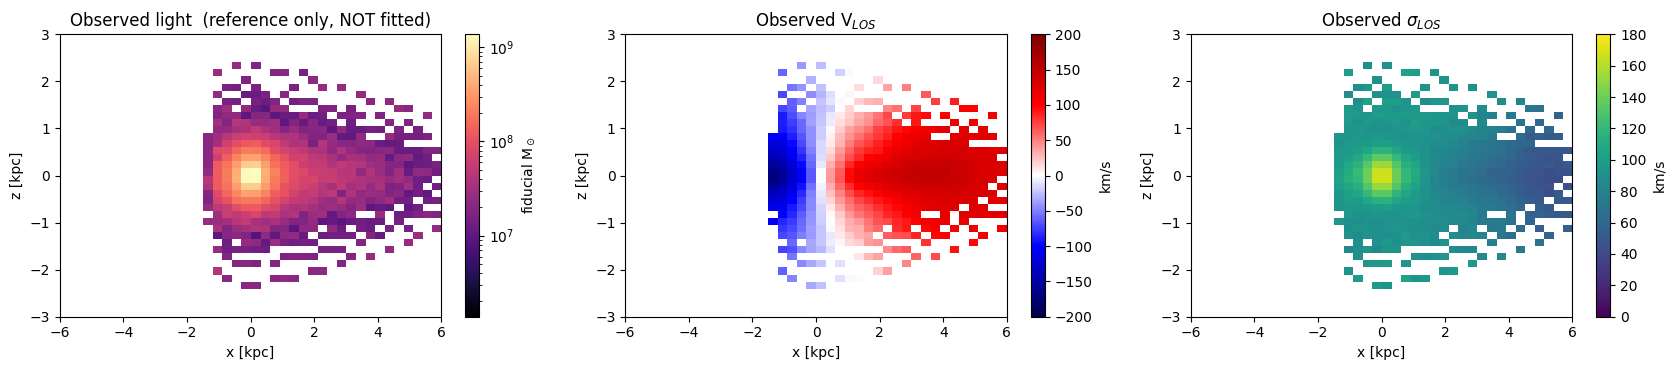

In [3]:
EXTENT = [-EXTENT_X, EXTENT_X, -EXTENT_Z, EXTENT_Z]

def masked(a):
    return np.where(data_mask, np.array(a), np.nan)

fig, axes = plt.subplots(1, 3, figsize=(17, 3.8))
im = axes[0].imshow(masked(obs_maps['mass']), origin='lower', extent=EXTENT, cmap='magma',
                    norm=LogNorm(vmin=vmax_mass / 1e3, vmax=vmax_mass), aspect='auto')
axes[0].set_title('Observed light  (reference only, NOT fitted)')
fig.colorbar(im, ax=axes[0], label='fiducial M$_\\odot$')
im = axes[1].imshow(masked(obs_maps['v_rot']), origin='lower', extent=EXTENT,
                    cmap='seismic', vmin=-200, vmax=200, aspect='auto')
axes[1].set_title('Observed V$_{LOS}$'); fig.colorbar(im, ax=axes[1], label='km/s')
im = axes[2].imshow(masked(obs_maps['sigma']), origin='lower', extent=EXTENT,
                    cmap='viridis', vmin=0, vmax=180, aspect='auto')
axes[2].set_title('Observed $\\sigma_{LOS}$'); fig.colorbar(im, ax=axes[2], label='km/s')
for ax in axes:
    ax.set_xlabel('x [kpc]'); ax.set_ylabel('z [kpc]')
plt.tight_layout(); plt.show()

Note the two features that drive the modelling choices: a clean rotation dipole in `V_LOS` (so the disk must rotate coherently — hence the small `L0` bound), and a strong central `sigma` peak (so the bulge must be dispersion-supported — hence `spheroid_corotation = 0.5` and the cap on the disk dispersion). Note also that the coverage is markedly one-sided, while the model is axisymmetric; the comparison is therefore only made where data exist.

## 2. Fit Configuration

`OBS_BANDWIDTH` deserves a comment. In the mock it was known exactly (the bandwidth the observation was binned with). Here it is a **modelling choice**: the data's effective resolution comes from seeing (~0.8" ≈ 0.12 kpc at this distance), the Voronoi binning, and the 0.3 kpc grid cell. Fitting below that would chase noise, so 0.4 kpc is used as both the annealing floor and the resolution the observation is treated as having. It is not a measured PSF width.

The two fits differ **only** in the bandwidth schedule, so the comparison is fair:

- naive: constant bandwidth, `anneal_bandwidth=(0.4, 0.4)`
- annealed: `anneal_bandwidth=(4.0, 0.4)`

Both pass `obs_bandwidth=0.4`, so at the final bandwidth no blurring is applied to the data and both fits end up optimizing exactly the same objective — only the path there differs.


### Note on the annealing schedule

`fit` now uses a **ramp-and-hold** bandwidth schedule when `obs_bandwidth` is set (`anneal_hold_frac`, default 0.35): matching the data's resolution requires blurring it by `sqrt(h**2 - obs_bandwidth**2)`, and `blur_maps` works on the binned grid, so it cannot represent a blur much narrower than a pixel — the data stops being blurred while the model's KDE genuinely is smoother, leaving a systematic mismatch that does not vanish at the true parameters. The schedule therefore ramps down only to where that blur is still ~0.5 pixel and then jumps to `obs_bandwidth`, holding there.

**How much this matters here: very little.** The affected band is `h` between `obs_bandwidth` and `sqrt(obs_bandwidth**2 + (0.5*pixel)**2)`. With 0.3-0.35 kpc pixels and `obs_bandwidth = 0.4` kpc that band is only ~7-9% of `obs_bandwidth` wide, against ~124% for the coarse-gridded mock notebook (2.14 kpc pixels), where the artifact cost a factor ~26 in the loss at the true parameters. So the annealed fit below should be nearly unchanged, and any naive-vs-annealed verdict should stand on its own merits rather than on this artifact. The naive fit uses a constant bandwidth, so it is unaffected either way.

### A second, deeper caveat found while testing this

Restricting the loss to the observed footprint (now done automatically: the mask is taken from the *unblurred* maps and held fixed) removed a large error — on this pointing the blurred mask had grown from the real **473 cells to all 1600**, so most of the annealing phase was scoring the model against ~1100 pixels of flux that blurring had invented. At the final fitted parameters that inflation accounted for ~40% of the loss at h = 2 kpc (0.476 -> 0.277).

But a residual problem remains, and it is intrinsic to blurring *real* data with partial coverage. Evaluated at fixed parameters, the loss still varies ~5x with bandwidth (0.194 at h=4, peaking 0.277 at h=2, down to 0.056 at h=0.4). Two reasons: the observation is not actually a Gaussian KDE at `obs_bandwidth` (it is flux summed into cells, so blurring it does not reproduce what the model's KDE at h produces), and the footprint has a hard edge which blurring smears into a soft one that the model — which extends beyond the observed region — cannot match.

**Practical conclusion for these fits: do not anneal.** The constant-bandwidth ("naive") run compares like with like at every step, and it already reaches the same solution as the annealed run. Annealing exists to cure the vanishing gradient of the masked log-*mass* term, which is switched off here; on kinematic maps with partial coverage it buys nothing and its intermediate objectives are distorted.

In [4]:
N_PARTICLES = 20_000       # fit_geckos.py uses 35_000 for production; reduced here for runtime
N_PARTICLES_RENDER = 100_000
N_STEPS = 600
SEED = 0
LEARNING_RATE = 0.05
OBS_BANDWIDTH = 0.4                     # see the note above
LOSS_WEIGHTS = (0.0, 2.0, 3.0, 0.0)     # (mass, v_rot, sigma, poisson): kinematic-only
REG_WEIGHT = 0.05                       # mild prior toward the initial guess

init_pot = {'M_halo': 4e11, 'a_halo': 10.0, 'M_disk': 4e10, 'a_disk': 2.5,
            'b_disk': 0.3, 'M_bulge': 3e10, 'a_bulge': 0.3}
init_disk = {'R0': 4.0, 'Rd': 1.5, 'Sigma0': 1000.0, 'RsigR': 5.0, 'RsigZ': 5.0,
             'sigmaR0_R0': 60.0, 'sigmaz0_R0': 40.0, 'L0': 3.0, 'Rinit_for_Rc': 4.0}
init_bulge = {'N0_spheroid': 3e10, 'J0_spheroid': 25.0, 'Gamma_spheroid': 1.5,
              'Beta_spheroid': 4.5, 'eta_spheroid': 1.0}

param_bounds = copy.deepcopy(DEFAULT_PARAM_BOUNDS)
param_bounds['disk']['L0'] = (2.0, 5.0)             # coherent disk rotation
param_bounds['disk']['sigmaR0_R0'] = (5.0, 120.0)   # cap the disk: the sigma peak
param_bounds['disk']['sigmaz0_R0'] = (5.0, 90.0)    #   must come from the bulge

FIT_KW = dict(
    N_disk=N_PARTICLES, N_bulge=N_PARTICLES, grid_size=GRID_SIZE,
    extent_x=EXTENT_X, extent_z=EXTENT_Z, prng_seed=SEED,
    loss_weights=LOSS_WEIGHTS, poisson_kwargs={},
    learning_rate=LEARNING_RATE, n_steps=N_STEPS,
    spheroid_corotation=SPHEROID_COROTATION, param_bounds=param_bounds,
    obs_bandwidth=OBS_BANDWIDTH, reg_weight=REG_WEIGHT,
)

### Which parameters can this dataset actually constrain?

Before fitting, measure it. `Sigma0` and `N0_spheroid` are *structurally* degenerate for any dataset — the tracer weights are renormalized (`w / sum(w) * M_disk`), so an overall DF amplitude cancels exactly. Others may be degenerate for *this* loss. Anything with a numerically zero gradient can only drift, so it is frozen.

In [5]:
probe_loss = make_loss_fn(
    mapper := PhoenixMapper(), obs_maps,
    N_disk=N_PARTICLES, N_bulge=N_PARTICLES, grid_size=GRID_SIZE,
    extent_x=EXTENT_X, extent_z=EXTENT_Z, prng_seed=SEED,
    loss_weights=LOSS_WEIGHTS, poisson_kwargs={},
    spheroid_corotation=SPHEROID_COROTATION, obs_bandwidth=OBS_BANDWIDTH,
)
(_l, _a), grads = jax.value_and_grad(probe_loss, has_aux=True)(
    params_to_log(init_pot, init_disk, init_bulge), OBS_BANDWIDTH)

print("|d loss / d log(param)| at the initial guess:")
flat = []
for group in ('pot', 'disk', 'bulge'):
    for k, g in grads[group].items():
        flat.append((abs(float(g)), group, k))
for mag, group, k in sorted(flat, reverse=True):
    tag = '   <-- numerically zero: unconstrained' if mag < 1e-6 else ''
    print(f"  {group:6s} {k:16s} {mag:.3e}{tag}")

FROZEN = tuple(k for mag, _, k in flat if mag < 1e-6)
print(f"\nfreezing: {FROZEN}")

Loading Phoenix Surrogate Model...
 -> Weights: /home/annalena/phoenix/phoenix/torus_mapping_neural_network/phoenix_weights.msgpack
 -> Stats:   /home/annalena/phoenix/phoenix/torus_mapping_neural_network/phoenix_norm_stats.npz


Model loaded and ready for inference!


|d loss / d log(param)| at the initial guess:
  pot    M_bulge          2.383e+00
  pot    a_halo           1.240e+00
  pot    M_disk           6.846e-01
  pot    M_halo           3.254e-01
  pot    a_disk           2.973e-01
  pot    a_bulge          2.484e-01
  disk   Rd               1.810e-01
  disk   RsigR            1.601e-01
  disk   RsigZ            1.193e-01
  disk   R0               7.738e-02
  disk   sigmaz0_R0       7.237e-02
  pot    b_disk           6.940e-02
  disk   sigmaR0_R0       2.435e-02
  bulge  Beta_spheroid    2.028e-03
  bulge  J0_spheroid      4.986e-04
  bulge  Gamma_spheroid   4.413e-04
  bulge  eta_spheroid     1.918e-04
  disk   L0               7.170e-05
  disk   Sigma0           3.638e-09   <-- numerically zero: unconstrained
  bulge  N0_spheroid      1.100e-10   <-- numerically zero: unconstrained
  disk   Rinit_for_Rc     1.114e-17   <-- numerically zero: unconstrained

freezing: ('Rinit_for_Rc', 'Sigma0', 'N0_spheroid')


## 3. Naive Fit — Constant Bandwidth

In [6]:
result_naive = fit(mapper, obs_maps, init_pot, init_disk, init_bulge,
                   anneal_bandwidth=(OBS_BANDWIDTH, OBS_BANDWIDTH),
                   frozen_params=FROZEN, **FIT_KW)
hn = result_naive['history']
print(f"NAIVE   loss {hn['loss'][0]:8.4f} -> {hn['loss'][-1]:8.4f}"
      + ('   [NaN!]' if not np.isfinite(hn['loss'][-1]) else ''))
print(f"        v_rot {hn['vrot_loss'][-1]:.4f}   sigma {hn['sigma_loss'][-1]:.4f}"
      f"   reg {hn['reg'][-1]:.4f}")

NAIVE   loss   1.8175 ->   0.0632
        v_rot 0.0114   sigma 0.0111   reg 0.0070


## 4. Annealed Fit — Coarse-to-Fine, With the Data Blurred to Match

In [7]:
result = fit(mapper, obs_maps, init_pot, init_disk, init_bulge,
             anneal_bandwidth=(4.0, OBS_BANDWIDTH),
             frozen_params=FROZEN, **FIT_KW)
h = result['history']
print(f"ANNEALED loss {h['loss'][0]:8.4f} -> {h['loss'][-1]:8.4f}"
      + ('   [NaN!]' if not np.isfinite(h['loss'][-1]) else ''))
print(f"         v_rot {h['vrot_loss'][-1]:.4f}   sigma {h['sigma_loss'][-1]:.4f}"
      f"   reg {h['reg'][-1]:.4f}")
better = 'annealed' if h['loss'][-1] < hn['loss'][-1] else 'naive'
print(f"\nlower final loss: {better}")

ANNEALED loss   0.6819 ->   0.0838
         v_rot 0.0154   sigma 0.0117   reg 0.0179

lower final loss: naive


In [8]:
# Persist the expensive results so downstream cells (or a later crash) never cost
# another full refit. Reload with json.load(open('NGC3630_fit_results.json')).
import json as _json
with open(f'{NAME}_fit_results.json', 'w') as _fh:
    _json.dump({
        'galaxy': NAME,
        'config': {'D_MPC': D_MPC, 'LMSTAR': LMSTAR, 'GRID_SIZE': GRID_SIZE,
                   'EXTENT_X': EXTENT_X, 'EXTENT_Z': EXTENT_Z,
                   'N_PARTICLES': N_PARTICLES, 'N_STEPS': N_STEPS,
                   'OBS_BANDWIDTH': OBS_BANDWIDTH, 'LOSS_WEIGHTS': list(LOSS_WEIGHTS),
                   'REG_WEIGHT': REG_WEIGHT, 'FROZEN': list(FROZEN),
                   'SPHEROID_COROTATION': SPHEROID_COROTATION},
        'annealed': {'pot_params': {k: float(v) for k, v in result['pot_params'].items()},
                     'disk_df_params': {k: float(v) for k, v in result['disk_df_params'].items()},
                     'bulge_df_params': {k: float(v) for k, v in result['bulge_df_params'].items()},
                     'final_loss': float(h['loss'][-1])},
        'naive': {'pot_params': {k: float(v) for k, v in result_naive['pot_params'].items()},
                  'disk_df_params': {k: float(v) for k, v in result_naive['disk_df_params'].items()},
                  'bulge_df_params': {k: float(v) for k, v in result_naive['bulge_df_params'].items()},
                  'final_loss': float(hn['loss'][-1])},
    }, _fh, indent=2)
print(f'wrote {NAME}_fit_results.json')

wrote NGC3630_fit_results.json


## 5. Convergence

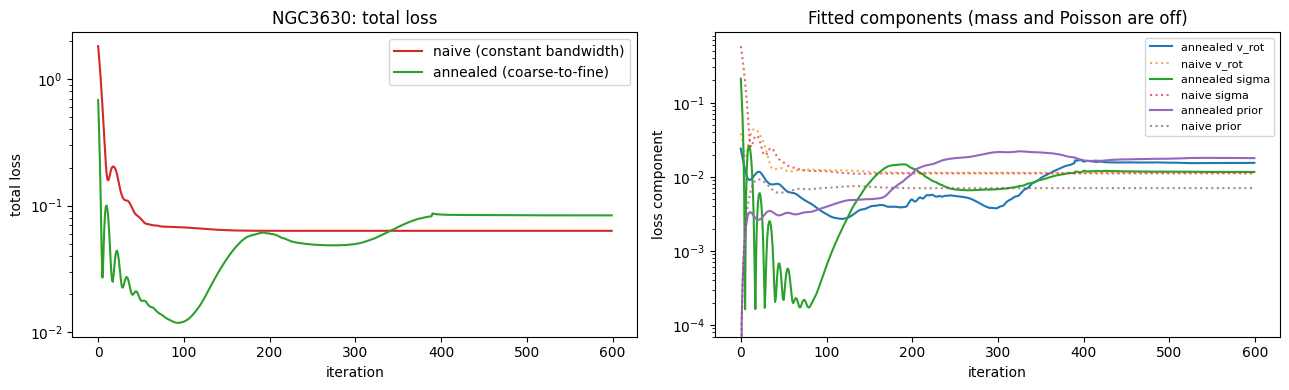

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(hn['loss'], color='tab:red', label='naive (constant bandwidth)')
axes[0].plot(h['loss'], color='tab:green', label='annealed (coarse-to-fine)')
axes[0].set_yscale('log'); axes[0].set_xlabel('iteration'); axes[0].set_ylabel('total loss')
axes[0].set_title(f'{NAME}: total loss'); axes[0].legend()

for key, lab in [('vrot_loss', 'v_rot'), ('sigma_loss', 'sigma'), ('reg', 'prior')]:
    axes[1].plot(h[key], label=f'annealed {lab}')
    axes[1].plot(hn[key], ls=':', alpha=0.7, label=f'naive {lab}')
axes[1].set_yscale('log'); axes[1].set_xlabel('iteration'); axes[1].set_ylabel('loss component')
axes[1].set_title('Fitted components (mass and Poisson are off)'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 6. Maps and Residuals

The fitted models are rendered with many more tracers than the fit itself used (`render_maps_batched`, chunked so the dense kernel array stays within memory) and at the bandwidth the fit converged to. This removes Monte-Carlo graininess so the model maps are as smooth as the Voronoi-binned data, without changing the physics.

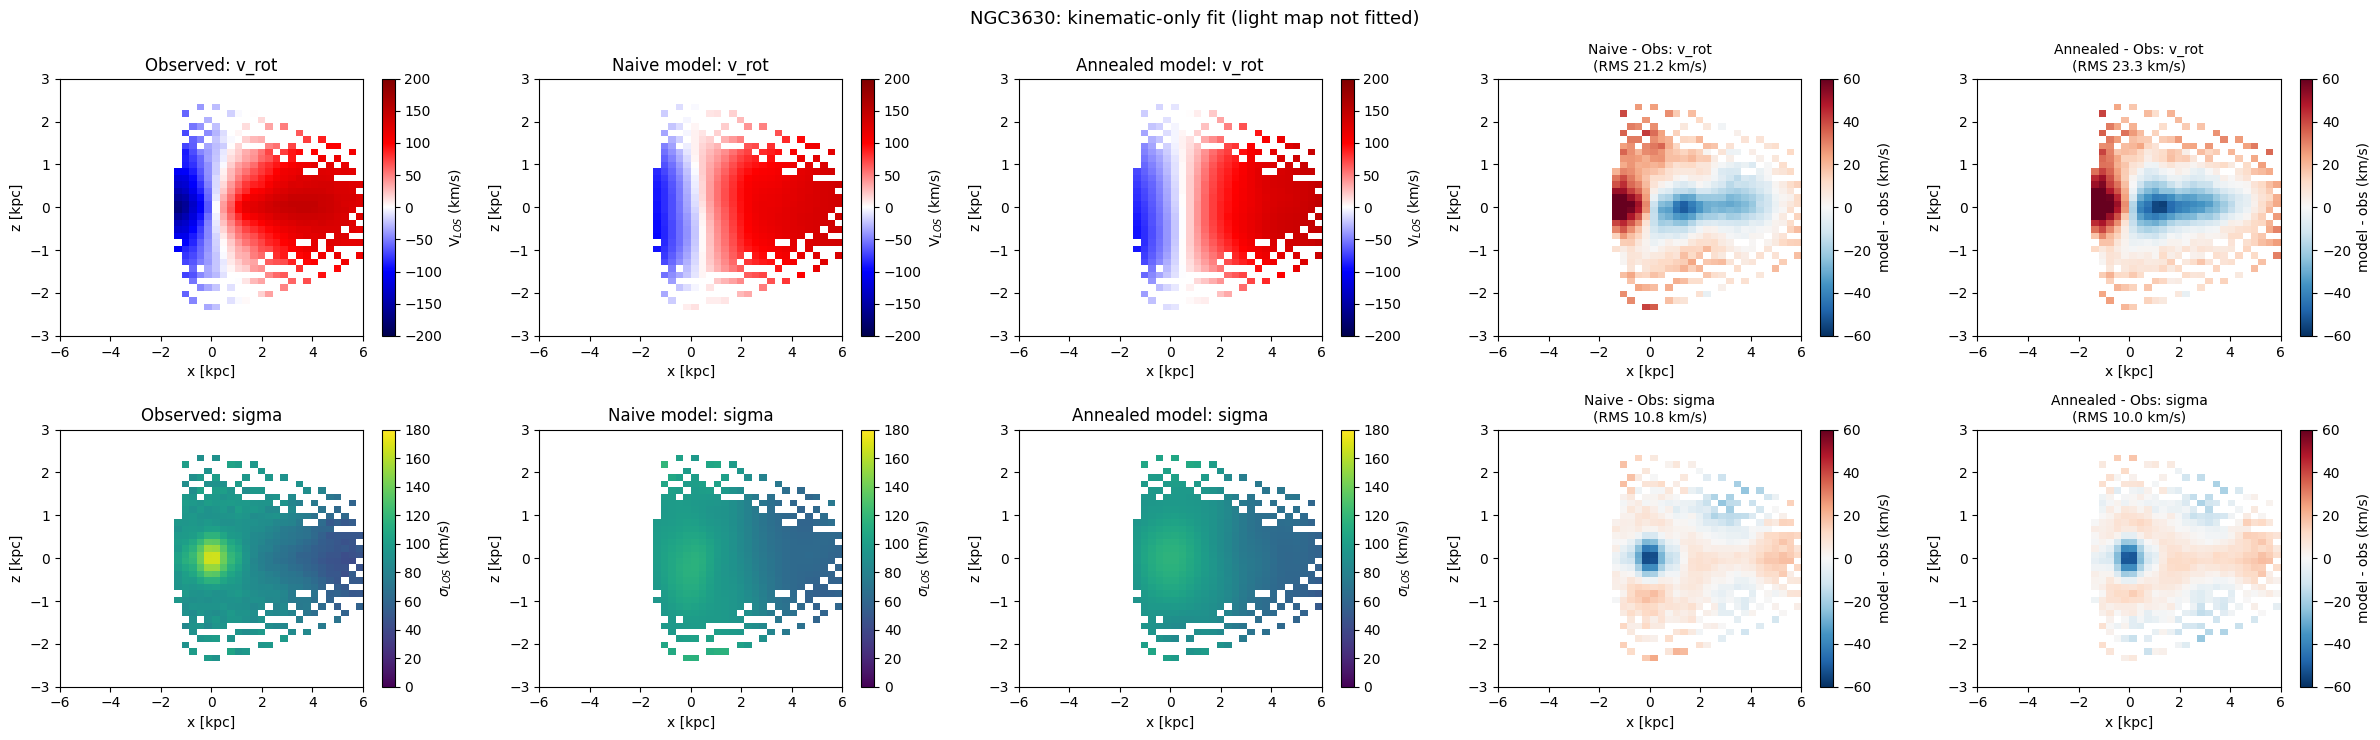

Residuals over the 473 cells with data:
  v_rot  naive   : RMS  21.17 km/s   median  +6.78   max|.|  79.71
  v_rot  annealed: RMS  23.31 km/s   median  +7.07   max|.|  85.79
  sigma  naive   : RMS  10.85 km/s   median  +2.91   max|.|  53.60
  sigma  annealed: RMS  10.02 km/s   median  +2.12   max|.|  50.86


In [10]:
render_kw = dict(N_disk=N_PARTICLES_RENDER, N_bulge=N_PARTICLES_RENDER,
                 grid_size=GRID_SIZE, extent_x=EXTENT_X, extent_z=EXTENT_Z,
                 prng_seed=SEED, soft_bin_h=OBS_BANDWIDTH,
                 spheroid_corotation=SPHEROID_COROTATION, chunk=15_000)

maps_anneal = render_maps_batched(mapper, result['pot_params'], result['disk_df_params'],
                                 result['bulge_df_params'], **render_kw)
maps_naive = render_maps_batched(mapper, result_naive['pot_params'],
                                 result_naive['disk_df_params'],
                                 result_naive['bulge_df_params'], **render_kw)

specs = [('v_rot', 'seismic', dict(vmin=-200, vmax=200), 'V$_{LOS}$ (km/s)'),
         ('sigma', 'viridis', dict(vmin=0, vmax=180), '$\\sigma_{LOS}$ (km/s)')]

fig, axes = plt.subplots(2, 5, figsize=(24, 7.5))
for row, (key, cmap, kw, label) in enumerate(specs):
    panels = [('Observed', obs_maps[key]), ('Naive model', maps_naive[key]),
              ('Annealed model', maps_anneal[key])]
    for col, (t, arr) in enumerate(panels):
        im = axes[row, col].imshow(masked(arr), origin='lower', extent=EXTENT,
                                   cmap=cmap, aspect='auto', **kw)
        axes[row, col].set_title(f'{t}: {key}')
        fig.colorbar(im, ax=axes[row, col], label=label)
    for col, (t, arr) in enumerate([('Naive', maps_naive[key]),
                                    ('Annealed', maps_anneal[key])], start=3):
        d = np.where(data_mask, np.array(arr) - np.array(obs_maps[key]), np.nan)
        rms = float(np.sqrt(np.nanmean(d ** 2)))
        im = axes[row, col].imshow(d, origin='lower', extent=EXTENT, cmap='RdBu_r',
                                   vmin=-60, vmax=60, aspect='auto')
        axes[row, col].set_title(f'{t} - Obs: {key}\n(RMS {rms:.1f} km/s)', fontsize=10)
        fig.colorbar(im, ax=axes[row, col], label='model - obs (km/s)')
for ax in axes.ravel():
    ax.set_xlabel('x [kpc]'); ax.set_ylabel('z [kpc]')
fig.suptitle(f'{NAME}: kinematic-only fit (light map not fitted)', fontsize=13)
plt.tight_layout(); plt.show()

print(f"Residuals over the {int(data_mask.sum())} cells with data:")
for key in ('v_rot', 'sigma'):
    o = np.array(obs_maps[key])
    for tag, m in [('naive   ', maps_naive[key]), ('annealed', maps_anneal[key])]:
        d = np.where(data_mask, np.array(m) - o, np.nan)
        print(f"  {key:6s} {tag}: RMS {np.sqrt(np.nanmean(d**2)):6.2f} km/s   "
              f"median {np.nanmedian(d):+6.2f}   max|.| {np.nanmax(np.abs(d)):6.2f}")

## 7. Fitted Parameters

There is **no ground truth**, so these are answers rather than scores. The comparison worth making is naive vs annealed: parameters that agree between two different optimization paths are more trustworthy than ones that do not. Parameters sitting exactly on a bound are flagged — there the bound, not the data, is setting the value.

In [11]:
import math

def flat_params(res):
    return {**res['pot_params'], **res['disk_df_params'], **res['bulge_df_params']}

pa, pn = flat_params(result), flat_params(result_naive)
init_all = {**init_pot, **init_disk, **init_bulge}
bounds_all = {**param_bounds['pot'], **param_bounds['disk'], **param_bounds['bulge']}


def bound_flag(v, lo, hi, frac=0.02):
    """How close v sits to its bounds, measured in LOG space -- which is the space the
    optimizer actually works in, and the only sensible one when a bound range spans
    orders of magnitude (M_bulge is allowed 1e7..5e11, so a linear 'within 2% of the
    range' test would call 6e9 'at the lower bound' when it is 600x above it)."""
    if lo > 0 and v > 0 and hi > lo:
        f = (math.log(v) - math.log(lo)) / (math.log(hi) - math.log(lo))
    elif hi > lo:
        f = (v - lo) / (hi - lo)            # e.g. Gamma_spheroid, whose lower bound is 0
    else:
        return ''
    if f <= frac:
        return 'AT LOWER BOUND'
    if f >= 1.0 - frac:
        return 'AT UPPER BOUND'
    return ''


print(f"{'parameter':16s} {'init':>11s} {'naive':>11s} {'annealed':>11s} {'ann/naive':>10s}  notes")
for k in init_all:
    a, n = float(pa[k]), float(pn[k])
    lo, hi = bounds_all[k]
    notes = []
    if k in FROZEN:
        notes.append('frozen (unconstrained)')
    bf = bound_flag(a, lo, hi)
    if bf:
        notes.append(bf)
    ratio = (a / n) if n != 0 else float('nan')
    if k not in FROZEN and (ratio > 1.5 or ratio < 1 / 1.5):
        notes.append('PATHS DISAGREE -> not constrained')
    # A parameter that barely moved from its start, with a tiny gradient, is being held
    # by the Tikhonov prior rather than by the data. Flag that so it is not read as a
    # measurement.
    if k not in FROZEN and abs(a / init_all[k] - 1.0) < 0.05 and REG_WEIGHT > 0:
        notes.append('~unmoved: set by the prior, not the data')
    print(f"{k:16s} {init_all[k]:11.4g} {n:11.4g} {a:11.4g} {ratio:10.2f}  {', '.join(notes)}")

parameter               init       naive    annealed  ann/naive  notes
M_halo                 4e+11   2.734e+11   2.976e+11       1.09  
a_halo                    10       26.62       13.95       0.52  PATHS DISAGREE -> not constrained
M_disk                 4e+10   6.851e+10   3.951e+10       0.58  PATHS DISAGREE -> not constrained, ~unmoved: set by the prior, not the data
a_disk                   2.5       5.098       2.457       0.48  PATHS DISAGREE -> not constrained, ~unmoved: set by the prior, not the data
b_disk                   0.3      0.2234      0.3314       1.48  
M_bulge                3e+10   1.413e+10   4.683e+09       0.33  PATHS DISAGREE -> not constrained
a_bulge                  0.3      0.3357        1.96       5.84  PATHS DISAGREE -> not constrained
R0                         4       4.746       4.168       0.88  ~unmoved: set by the prior, not the data
Rd                       1.5        1.07       1.108       1.04  
Sigma0                  1000        1000      

## 8. Summary and Caveats

**What was fitted:** the line-of-sight velocity and dispersion maps of NGC 3630, with `sigma` up-weighted. The light map and the Poisson self-consistency term were both off — see the table at the top for why each.

**What to take from the naive/annealed comparison:** the two runs optimize an identical objective at the final bandwidth and differ only in the path taken, so the lower final loss is the better optimum, and the residual maps show where the idealized model cannot follow the real galaxy.

**Caveats that apply to any conclusion drawn here:**

- **No ground truth.** A good map fit does not imply the parameters are right; the DF *shape* parameters in particular are weakly constrained even in a controlled mock, and an edge-on projection under-constrains them further.
- **Light is not mass.** The mass map's normalization is fiducial (catalogue M*), so `M_disk`/`M_bulge` absorb the M/L assumption. Only the velocities carry an absolute physical scale.
- **Self-consistency is not enforced.** The fitted model is not guaranteed to be a dynamically self-consistent galaxy. Re-enabling the Poisson weight would impose that as a prior, but unlike the mock there is no way to check it is compatible with this galaxy first.
- **One-sided coverage, axisymmetric model.** ~30% of cells have data and mostly on one side; the model is axisymmetric by construction, so the fit is effectively constrained by one side of the disk plus the nucleus.
- **Reduced tracer count.** `N_PARTICLES = 20_000` and 600 steps here for runtime; `fit_geckos.py` uses 35,000 and 700 for production. The Monte-Carlo noise floor is correspondingly a little higher than it needs to be.
- **Distance and M\* are catalogue values**, entering as `kpc/arcsec` and the mass normalization; an error there propagates directly into the inferred masses and scale lengths.